# Lesson 01 — Tree Prediction Geometry and Terminology

## Goals, prerequisites, and scope

By the end of this lesson, you should be able to:

- use *feature*, *threshold*, *branch*, *internal node*, *leaf*, *region*, and *leaf prediction* precisely;
- explain why a regression leaf returns one shared target mean;
- translate among a threshold rule, a two-leaf tree diagram, and a piecewise-constant prediction plot; and
- implement and check a one-feature regression stump predictor.

**Prerequisites.** Python, NumPy and pandas basics, and experience calling a decision-tree model. Knowledge of CART internals is not required.

**Scope boundary.** We choose one transparent threshold manually. Finding the best split, impurity reduction, recursion, and boosting belong to later lessons.

## Mental model: a leaf stores one shared prediction

A regression tree first uses feature thresholds to route an observation to a leaf. Think of each leaf as a region, or bucket, with one numerical label attached to it. Once an observation reaches that leaf, the model returns the attached value; it does not calculate or store a separate value for each future observation.

In Python-like pseudocode, a two-leaf tree behaves like this:

```python
if med_inc <= threshold:
    return left_leaf_prediction
return right_leaf_prediction
```

Therefore, two observations routed to the same leaf receive the same prediction even when their feature values and true target values differ. A target mean is a sensible shared regression prediction because it is the region's numerical center: values above and below it balance one another. Under squared error, that mean is the best single constant for the region; choosing the threshold itself remains outside this lesson.

## Tree terminology

A **regression stump** is the smallest complete regression tree: one internal node, one threshold decision, two branches, and two leaves.

| Term | Meaning in this lesson |
|---|---|
| **Feature** | Numerical input used by a decision, here `MedInc` |
| **Threshold** | Cutoff compared with the feature, here `4.0` |
| **Internal node** | A decision point that applies the threshold rule |
| **Branch** | One outcome of the decision: left (`≤`) or right (`>`) |
| **Region** | Feature values that follow the same branch to a leaf |
| **Leaf** | Endpoint of the tree that stores a prediction |
| **Leaf prediction** | One numerical value returned for every observation in that region |

## California Housing columns and units

Each row describes a California census block group rather than one household or one house. The monetary columns are scaled so that the dataset contains small numerical values:

| Column | Model role | Stored unit | Example |
|---|---|---:|---:|
| `MedInc` | Feature: median household income in the block group | \$10,000 | `3.5` means about \$35,000 |
| `MedHouseVal` | Continuous target: median house value in the block group | \$100,000 | `2.4` means about \$240,000 |

These are historical values derived from the 1990 U.S. Census, not present-day dollar amounts. The target was capped near \$500,000 in the source data, which appears here as a maximum around `5.00001`; block groups at that ceiling did not necessarily have identical uncapped median house values.

## Set up and inspect California Housing

We use `MedInc` as the single feature and `MedHouseVal` as the continuous target. Before selecting a small slice, `describe()` confirms the number of available block groups and the numerical range of both columns.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing

# Request a labeled pandas frame so feature and target names remain visible.
housing = fetch_california_housing(as_frame=True)

# Keep only the one feature and continuous target used in this lesson.
housing_rows = housing.frame.loc[:, ["MedInc", "MedHouseVal"]]

# Check the row count, center, spread, and observed range before sampling.
housing_rows.describe()

,MedInc,MedHouseVal
count,20640.000000,20640.000000
mean,3.870671,2.068558
std,1.899822,1.153956
min,0.499900,0.149990
25%,2.563400,1.196000
50%,3.534800,1.797000
75%,4.743250,2.647250
max,15.000100,5.000010


## Select a deterministic 12-row slice

A small table makes the threshold and leaf calculations inspectable by hand. We sort all rows by `MedInc` and select 12 evenly spaced **rank positions**—locations in the sorted row order, not evenly spaced income values. The fixed procedure covers the observed income range and returns the same real rows every time.

`reset_index(names="source_row")` preserves each row's original dataset index as an identifier before sorting. The final `reset_index(drop=True)` gives the displayed slice clean row labels from `0` to `11`; `source_row` remains metadata for traceability and is never used as a model feature.

**Before splitting:** scan the visible targets. House values tend to be higher among higher-income rows, but they do not increase perfectly. A stump will summarize each region with one value rather than memorize every target.

In [2]:
# Preserve original row identifiers and use them to break income ties reproducibly.
sorted_rows = (
    housing_rows.reset_index(names="source_row")
    .sort_values(by=["MedInc", "source_row"])
    .reset_index(drop=True)
)

# Select 12 evenly spaced rank positions across the sorted real rows.
rank_positions = np.linspace(
    0,
    len(sorted_rows) - 1,
    num=12,
    dtype=int,
)

# Display the positions so the selection rule is visible and auditable.
print("Selected rank positions:", rank_positions)

# Materialize the selected rows as the small table used for hand reasoning.
housing_slice = sorted_rows.iloc[rank_positions].reset_index(drop=True)
housing_slice

Selected rank positions: [    0  1876  3752  5628  7505  9381 11257 13133 15010 16886 18762 20639]


,source_row,MedInc,MedHouseVal
0,73,0.4999,0.675
1,241,1.8472,1.370
2,3789,2.2756,2.214
3,19601,2.6406,1.297
4,5841,3.0179,2.725
5,5606,3.3427,1.542
6,19373,3.7031,1.733
7,6743,4.1136,2.799
8,16665,4.6071,2.399
9,8554,5.2500,2.472


## Manual threshold and leaf predictions

We manually choose `MedInc = 4.0`, representing a block-group median income of about \$40,000.
This threshold is intentionally transparent rather than optimized.

- **Left region:** `MedInc ≤ 4.0`
- **Right region:** `MedInc > 4.0`

Every row belongs to exactly one region. The mean `MedHouseVal` within each region becomes that
 leaf's shared prediction.

In [3]:
# Use an interpretable $40,000 cutoff; best-split search is outside this lesson.
THRESHOLD = 4.0

# Mark each row according to the threshold rule.
left_mask = housing_slice["MedInc"] <= THRESHOLD
right_mask = housing_slice["MedInc"] > THRESHOLD

# Every row must reach at least one branch, and no row may reach both.
assert (left_mask | right_mask).all()
assert not (left_mask & right_mask).any()

# This visible slice should contain seven left rows and five right rows.
assert left_mask.sum() == 7
assert right_mask.sum() == 5

# The mean target in each region becomes that leaf's shared prediction.
left_leaf_prediction = housing_slice.loc[left_mask, "MedHouseVal"].mean()
right_leaf_prediction = housing_slice.loc[right_mask, "MedHouseVal"].mean()

left_leaf_prediction, right_leaf_prediction

(np.float64(1.650857142857143), np.float64(3.2340000000000004))

## Prepare feature and target arrays

The visualization uses `x` for the visible `MedInc` feature values and `y` for the corresponding observed `MedHouseVal` targets. Converting the columns to NumPy arrays preserves their row order and makes element-wise thresholding explicit.

In [4]:
# Map the visible table columns to the x and y notation used below.
x = housing_slice["MedInc"].to_numpy()
y = housing_slice["MedHouseVal"].to_numpy()

## Two views of the same regression stump

The left panel shows the observed targets and the threshold that partitions them. The right panel
 replaces every target in a region with that region's mean target.

The horizontal lines are constant because each leaf stores one shared prediction. The jump at
 `MedInc = 4.0` is the same boundary represented by the tree's internal threshold node.

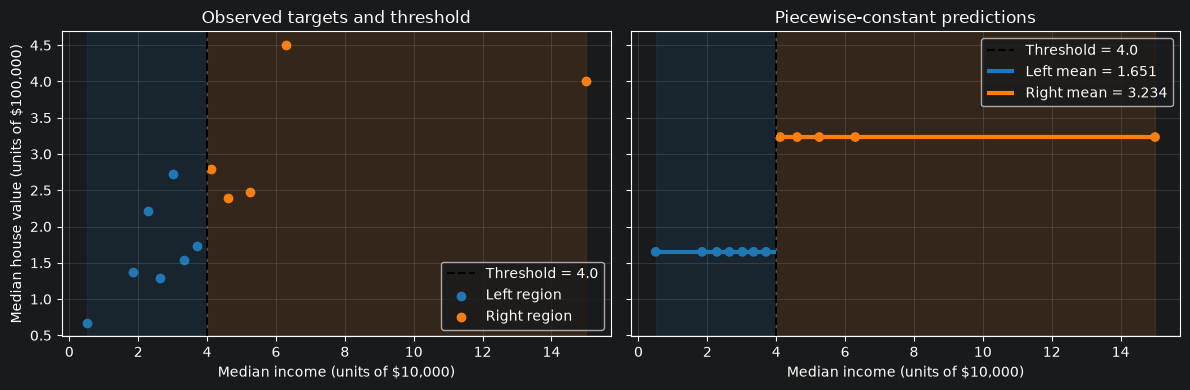

In [5]:
# Reapply the threshold to align plot colors and predictions with each x value.
is_left = x <= THRESHOLD

# Assign one of the two leaf values to every visible observation.
predictions = np.where(
    is_left,
    left_leaf_prediction,
    right_leaf_prediction,
)

# One prediction per row, using no more than two leaf values.
assert predictions.shape == y.shape
assert np.unique(predictions).size <= 2

fig, (target_ax, prediction_ax) = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    sharex=True,
    sharey=True,
)

for ax in (target_ax, prediction_ax):
    # Shade the two feature regions and mark their boundary.
    ax.axvspan(x.min(), THRESHOLD, color="tab:blue", alpha=0.12)
    ax.axvspan(THRESHOLD, x.max(), color="tab:orange", alpha=0.12)
    ax.axvline(THRESHOLD, color="black", linestyle="--", label="Threshold = 4.0")
    ax.set_xlabel(r"Median income (units of \$10,000)")
    ax.grid(alpha=0.25)

# Left panel: real target values.
target_ax.scatter(x[is_left], y[is_left], color="tab:blue", label="Left region")
target_ax.scatter(x[~is_left], y[~is_left], color="tab:orange", label="Right region")
target_ax.set_title("Observed targets and threshold")
target_ax.set_ylabel(r"Median house value (units of \$100,000)")
target_ax.legend()

# Right panel: the same model expressed as two horizontal steps.
prediction_ax.hlines(
    left_leaf_prediction,
    x.min(),
    THRESHOLD,
    color="tab:blue",
    linewidth=3,
    label=f"Left mean = {left_leaf_prediction:.3f}",
)
prediction_ax.hlines(
    right_leaf_prediction,
    THRESHOLD,
    x.max(),
    color="tab:orange",
    linewidth=3,
    label=f"Right mean = {right_leaf_prediction:.3f}",
)
prediction_ax.scatter(
    x,
    predictions,
    color=np.where(is_left, "tab:blue", "tab:orange"),
)
prediction_ax.set_title("Piecewise-constant predictions")
prediction_ax.legend()

fig.tight_layout()
plt.show()

## Interpret the tree and plot

The numerical tree and the right-hand plot encode the same prediction function:

```text
                 MedInc ≤ 4.0?
                /              \
       predict 1.651       predict 3.234
```

- Crossing from just below `4.0` to just above it changes the prediction from the left mean to the right mean.
- Two observations in one leaf cannot receive different stump predictions because that leaf stores one value.
- Each leaf in the diagram becomes one horizontal segment in the step plot; the segment's height is the leaf prediction.

### What if the threshold moves?

Moving the threshold from `4.0` to `5.0` transfers the rows with `MedInc` values `4.1136` and `4.6071` from right to left. Their targets are then added to the left mean and removed from the right mean, so both leaf predictions must be recomputed. This is a behavior experiment, not a search for the best threshold.

## Threshold notation and symbol-to-code mapping

For observation $i$, let $x_i$ be its `MedInc` feature and $y_i$ its observed `MedHouseVal` target. Given threshold $t$, the two regions are

$$
R_L(t) = \{i : x_i \le t\}, \qquad R_R(t) = \{i : x_i > t\}.
$$

Each leaf stores the mean target of the rows in its region:

$$
\mu_L = \frac{1}{|R_L|} \sum_{i \in R_L} y_i, \qquad
\mu_R = \frac{1}{|R_R|} \sum_{i \in R_R} y_i.
$$

The stump prediction is therefore

$$
\hat{y}(x) =
\begin{cases}
\mu_L, & x \le t, \\
\mu_R, & x > t.
\end{cases}
$$

| Symbol | Meaning | Notebook code |
|---|---|---|
| $x_i$ | income feature for row $i$ | `housing_slice["MedInc"]` |
| $y_i$ | observed target for row $i$ | `housing_slice["MedHouseVal"]` |
| $t$ | manual threshold | `THRESHOLD` |
| $R_L(t)$, $R_R(t)$ | left and right regions | `left_mask`, `right_mask` |
| $\mu_L$, $\mu_R$ | shared leaf predictions | `left_leaf_prediction`, `right_leaf_prediction` |
| $\hat{y}$ | prediction for each row | `predictions` |

## Implement a one-feature stump predictor

`predict_stump` packages the plotted threshold rule into a reusable function. It accepts a one-dimensional income array, the threshold, and the two leaf predictions; it returns one prediction per input value with the same array shape. The function performs prediction only—it does not choose the threshold or calculate the leaf means.

In [6]:
def predict_stump(
    med_inc: np.ndarray,
    threshold: float,
    left_prediction: float,
    right_prediction: float,
) -> np.ndarray:
    """Return one leaf prediction for every income value."""
    # Apply the same threshold rule to every income value at once.
    return np.where(med_inc <= threshold, left_prediction, right_prediction)

In [7]:
stump_predictions = predict_stump(
    x,
    THRESHOLD,
    left_leaf_prediction,
    right_leaf_prediction,
)

# One output for every input row.
assert stump_predictions.shape == x.shape

# A two-leaf stump can return at most two distinct values.
assert np.unique(stump_predictions).size <= 2

# The reusable function must reproduce the predictions used in the plot.
assert np.array_equal(stump_predictions, predictions)

stump_predictions

array([1.65085714, 1.65085714, 1.65085714, 1.65085714, 1.65085714,
       1.65085714, 1.65085714, 3.234     , 3.234     , 3.234     ,
       3.234     , 3.234     ])

## Mastery checkpoint and takeaway

My takeaway is that a regression stump uses one feature threshold at an internal node to route observations along left and right branches into two regions. Each region ends at a leaf that stores one prediction, here the mean target of the training observations in that region, so every observation reaching that leaf receives the same value. The two-leaf diagram shows the routing decisions, while the step plot shows the resulting prediction function: one horizontal segment per leaf with a jump at the threshold. If the threshold moves, some rows can switch regions, changing the target values included in each mean and therefore changing one or both leaf predictions.

For this slice, the manual rule `MedInc ≤ 4.0` predicts about `1.651` (roughly \$165,100), while `MedInc > 4.0` predicts about `3.234` (roughly \$323,400). This lesson explains how that fixed stump predicts; it does not decide whether `4.0` is the best threshold.

### Mastery check

I can now translate among the threshold rule, the two-leaf tree diagram, the region means in code, and the piecewise-constant prediction plot.